**Question 6**

**Does the value-attitude correlation vary between countries?**

**Phase 1: Regional Categorization**

To identify cross-national variance, individual countries are aggregated into cultural and geographic regions. This reduces statistical noise and highlights broad differences in how European social models influence the relationship between human values and political placement.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the pre-cleaned dataset
df = pd.read_csv("ess_cleaned_data.csv")

# Mapping ISO country codes to cultural regions
region_map = {
    'NO':'Nordic','FI':'Nordic','SE':'Nordic','DK':'Nordic','IS':'Nordic',
    'EE':'Post-Communist','PL':'Post-Communist','HU':'Post-Communist','CZ':'Post-Communist','SI':'Post-Communist',
    'DE':'Western', 'NL':'Western', 'FR':'Western', 'BE':'Western', 'AT':'Western', 'CH':'Western',
    'IT':'Southern', 'ES':'Southern', 'PT':'Southern', 'GR':'Southern'
}

# Creating the region column for comparative analysis
df['region'] = df['cntry'].map(region_map)

**Phase 2: Correlation Analysis by Region **

This phase addresses the extent to which the ten Schwartz value dimensions predict political attitudes (lrscale) across different regions. By iterating through the newly created regions, Pearson correlation coefficients are calculated to reveal divergence in value-attitude consistency.

In [2]:
# Defining the 10 Schwartz Value Dimensions
schwartz_values = [
    'Universalism', 'Benevolence', 'Tradition', 'Security', 'Conformity',
    'Self-Direction', 'Stimulation', 'Hedonism', 'Achievement', 'Power'
]

# Calculating correlations between values and political leaning per region
analysis_results = []
for region in df['region'].dropna().unique():
    region_subset = df[df['region'] == region]
    # Assessing the link between the 10 values and the Left-Right scale
    corrs = region_subset[schwartz_values + ['lrscale']].corr()['lrscale'].drop('lrscale')
    corrs['Region'] = region
    analysis_results.append(corrs)

# Consolidating results into a final analytical DataFrame
regional_variance_df = pd.DataFrame(analysis_results).set_index('Region')

**Phase 3: Visualizing Cross-National Variance**

The heatmap provides a visual representation of the variance requested in Question 6. Significant differences in color intensity or direction (positive vs. negative) across rows indicate that the predictive power of specific values is not uniform across Europe but is instead dependent on regional context.

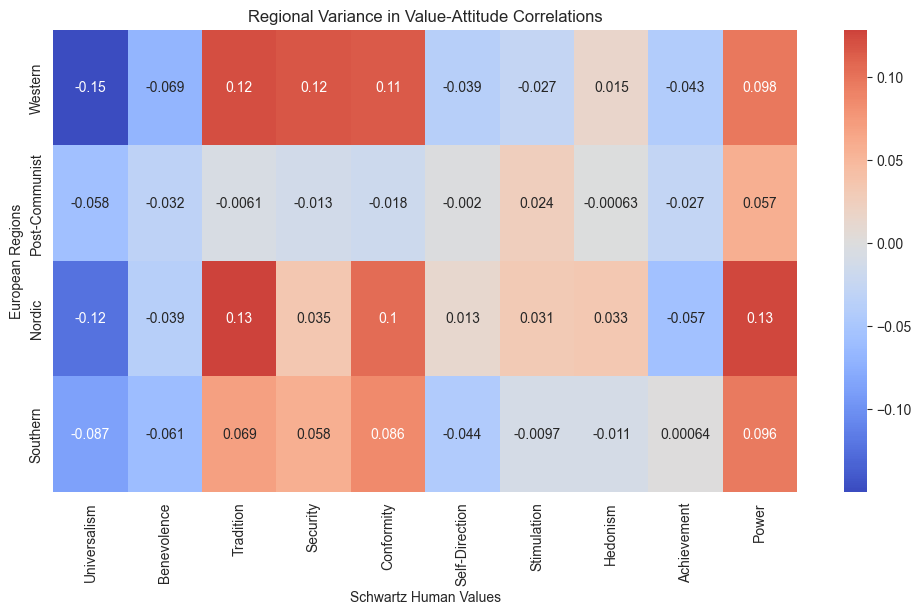

In [3]:
# Visualizing the strength and direction of correlations
plt.figure(figsize=(12, 6))
sns.heatmap(regional_variance_df, annot=True, cmap='coolwarm', center=0)
plt.title("Regional Variance in Value-Attitude Correlations")
plt.xlabel("Schwartz Human Values")
plt.ylabel("European Regions")
plt.show()

1. **General Key for Interpretation**

**Positive Values (Red)**: Indicate that as the value's importance increases, the respondent is more likely to identify with Right-wing politics (higher lrscale scores).

**Negative Values (Blue)**: Indicate that as the value's importance increases, the respondent is more likely to identify with Left-wing politics (lower lrscale scores).

**Near-Zero Values (Grey/White)**: Suggest that the value has little to no predictive power over political orientation in that specific region.

2. **Analysis of Regional Variance**
Universalism: The Most Consistent Predictor
Universalism shows a consistent negative correlation across all four regions (ranging from -0.058 to -0.15). This confirms that, regardless of geography, prioritizing social justice, equality, and environmental protection is a reliable predictor of Left-leaning attitudes. The effect is most pronounced in Western (-0.15) and Nordic (-0.12) regions.

**Tradition & Power**: The Right-Wing Anchors
Tradition: Shows the strongest positive correlation with Right-wing politics in the Nordic (0.13) and Western (0.12) regions. Interestingly, this link is nearly non-existent in the Post-Communist region (-0.0061), suggesting that "Tradition" may carry a different political connotation there.

**Power**: Consistently correlates with Right-wing placement across the board, peaking in the Nordic region (0.13).

Significant Regional Divergence: Security & Conformity
This is where the most "variance" is observed:

**Security**: In Western Europe, Security is a strong predictor of Right-wing orientation (0.12). However, in Post-Communist regions, the correlation is slightly negative (-0.013), and in the Nordic region, it is relatively weak (0.035).

**Conformity**: Similar to Security, Conformity is a meaningful predictor of Right-wing placement in Western (0.11), Nordic (0.1), and Southern (0.086) Europe, but shows a slight negative correlation in Post-Communist (-0.018) countries.

**3. Summary Conclusion**
To what extent do these correlations vary? The data suggests Moderate to High Variance.

**Uniformity**: Universalism and Power are relatively stable predictors of political leanings across the continent.

**Divergence**: The Post-Communist region is a significant outlier. Values that typically predict Right-leaning attitudes in the West (Tradition, Security, Conformity) show almost zero or even slightly negative predictive power in the Post-Communist context.

**Intensity**: The "Value-to-Politics" link appears overall stronger in Western and Nordic regions (deeper colors) than in Post-Communist regions (muted colors), indicating that human values may be more closely tied to political identity in established Western democracies.

The analysis therefore reveals that while Universalism and Power act as universal anchors for Left and Right ideologies respectively, the predictive power of Conservation values (Tradition, Security, Conformity) is highly dependent on regional context. Specifically, the Post-Communist region demonstrates a "decoupling" of traditional values from right-wing political identification, marking a significant divergence from the patterns observed in Western and Nordic Europe.